In [3]:
import numpy as np, json, pandas as pd
from statsbombpy import sb
import warnings
from statsbombpy.api_client import NoAuthWarning

warnings.filterwarnings("ignore", category=NoAuthWarning)

#  Load results 
coords_2d  = np.load('../models/coords_2d.npy')
labels     = np.load('../models/labels.npy')
player_ids = json.load(open('../models/player_ids.json'))

#  Build a name lookup from StatsBomb lineups 
#  pulls lineups from all matches in one season
print("Building player name lookup...")
name_lookup = {}
matches = sb.matches(competition_id=11, season_id=26)
for _, match in matches.iterrows():
    lineups = sb.lineups(match_id=match['match_id'])
    for team_df in lineups.values():
        for _, p in team_df.iterrows():
            name_lookup[str(p['player_id'])] = p['player_name']

print(f"Name lookup built: {len(name_lookup)} players")

#  Show cluster members 
df = pd.DataFrame({
    'player_id': player_ids,
    'label':     labels,
    'x':         coords_2d[:, 0],
    'y':         coords_2d[:, 1],
})
df['name'] = df['player_id'].map(lambda pid: name_lookup.get(str(pid), str(pid)))

for cid in sorted(set(labels)):
    if cid == -1:
        continue
    members = df[df['label'] == cid]['name'].tolist()
    print(f"\n Cluster {cid}  ({len(members)} players) ")
    print(', '.join(members[:12]))

Building player name lookup...
Name lookup built: 433 players

 Cluster 0  (86 players) 
11179.0, 4691.0, 27111.0, 26103.0, 6625.0, 26659.0, 24040.0, 10277.0, 11302.0, 6576.0, 6884.0, 27462.0

 Cluster 1  (149 players) 
3726.0, 3236.0, 6695.0, 24506.0, 27179.0, 6780.0, 27112.0, 27109.0, 23799.0, 10851.0, 26690.0, 24234.0

 Cluster 2  (90 players) 
5688.0, 6401.0, 6829.0, 11813.0, 24783.0, 22811.0, 6743.0, 27243.0, 16083.0, 6390.0, 11746.0, 6617.0

 Cluster 3  (79 players) 
5213.0, 10609.0, 5503.0, 5211.0, 20016.0, 5201.0, 5506.0, 5552.0, 4320.0, 5207.0, 5485.0, 20131.0

 Cluster 4  (124 players) 
5216.0, 5246.0, 4324.0, 6399.0, 5463.0, 4926.0, 5470.0, 19677.0, 5203.0, 3990.0, 6998.0, 5504.0

 Cluster 5  (186 players) 
5574.0, 6841.0, 6609.0, 5217.0, 25859.0, 6563.0, 3508.0, 6580.0, 6907.0, 27204.0, 6593.0, 26797.0

 Cluster 6  (122 players) 
3637.0, 6672.0, 10881.0, 8234.0, 25881.0, 27054.0, 6745.0, 6718.0, 4546.0, 3991.0, 25707.0, 6914.0

 Cluster 7  (49 players) 
6878.0, 6769.0, 2673

C:\Users\nimmi\AppData\Local\Temp\ipykernel_696\4008647936.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


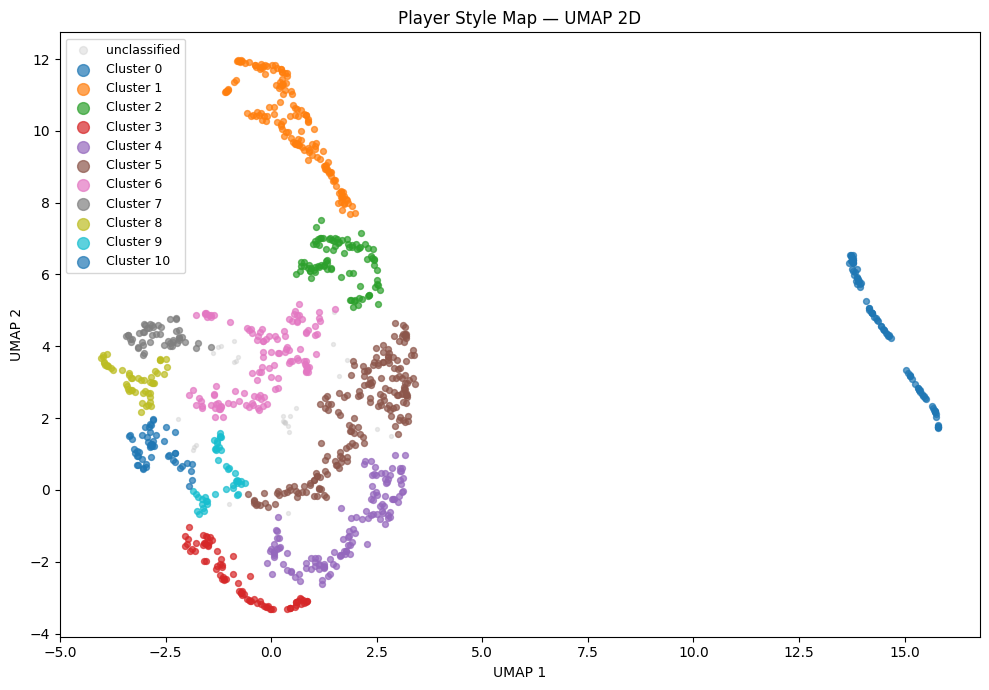

In [4]:
import matplotlib.pyplot as plt
import numpy as np

coords_2d = np.load('../models/coords_2d.npy')
labels    = np.load('../models/labels.npy')

fig, ax = plt.subplots(figsize=(10, 7))

# Plot noise points in light gray first
noise = labels == -1
ax.scatter(coords_2d[noise, 0], coords_2d[noise, 1],
           c='#cccccc', s=8, alpha=0.4, label='unclassified')

# Plot each cluster in a distinct colour
cmap = plt.cm.get_cmap('tab10')
for cid in sorted(set(labels)):
    if cid == -1: continue
    mask = labels == cid
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               c=[cmap(cid % 10)], s=18, alpha=0.7, label=f'Cluster {cid}')

ax.legend(markerscale=2, fontsize=9)
ax.set_title('Player Style Map — UMAP 2D')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import json
import pandas as pd
from statsbombpy import sb
from collections import defaultdict

In [6]:
coords_2d  = np.load("../models/coords_2d.npy")
labels     = np.load("../models/labels.npy")
player_ids = json.load(open("../models/player_ids.json"))

# keep ids consistent
player_ids = [str(p) for p in player_ids]

print("Players:", len(player_ids))
print("Coords shape:", coords_2d.shape)
print("Clusters:", len(set(labels)))

Players: 1059
Coords shape: (1059, 2)
Clusters: 12


In [7]:
print("\n=== coords_2d ===")
print("type:", type(coords_2d))
print("shape:", coords_2d.shape)
print("dtype:", coords_2d.dtype)
print("sample rows:\n", coords_2d[:5])

print("\n=== labels ===")
print("type:", type(labels))
print("shape:", labels.shape)
print("unique labels:", np.unique(labels)[:20])
print("sample:", labels[:20])

print("\n=== player_ids ===")
print("type:", type(player_ids))
print("length:", len(player_ids))
print("first 10:", player_ids[:10])
print("element type:", type(player_ids[0]))


=== coords_2d ===
type: <class 'numpy.ndarray'>
shape: (1059, 2)
dtype: float32
sample rows:
 [[-0.5627235  -3.0272698 ]
 [-0.51268286 -3.0629983 ]
 [ 0.6750565  -2.5479362 ]
 [ 0.5614605  -3.2546465 ]
 [13.769799    6.3349624 ]]

=== labels ===
type: <class 'numpy.ndarray'>
shape: (1059,)
unique labels: [-1  0  1  2  3  4  5  6  7  8  9 10]
sample: [ 3  3  4  3  0  4  3  3  3  3  5 -1  4  4  4  4  4  0  3  3]

=== player_ids ===
type: <class 'list'>
length: 1059
first 10: ['5213.0', '10609.0', '5216.0', '5503.0', '11179.0', '5246.0', '5211.0', '20016.0', '5201.0', '5506.0']
element type: <class 'str'>


In [8]:
print("\nAlignment check:")
print("coords:", len(coords_2d))
print("labels:", len(labels))
print("player_ids:", len(player_ids))

assert len(coords_2d) == len(labels) == len(player_ids), \
    " DATA MISALIGNMENT DETECTED"

print(" All arrays aligned")


Alignment check:
coords: 1059
labels: 1059
player_ids: 1059
 All arrays aligned


In [9]:
from statsbombpy import sb

matches = sb.matches(competition_id=11, season_id=26)
match_id = matches.iloc[0]["match_id"]

lineups = sb.lineups(match_id=match_id)

for team, df in lineups.items():
    print("\n==========================")
    print("TEAM:", team)
    print("Columns:")
    print(df.columns.tolist())
    print("\nSample rows:")
    print(df.head(3))
    break

for team, df in lineups.items():
    print("\nPosition-related columns:")
    cols = [c for c in df.columns if "position" in c.lower()]
    print(cols)
    print(df[cols].head())
    break


TEAM: Real Madrid
Columns:
['player_id', 'player_name', 'player_nickname', 'jersey_number', 'country', 'cards', 'positions']

Sample rows:
   player_id                     player_name player_nickname  jersey_number  \
0       3058       Javier Hernández Balcázar             NaN             14   
1       3990             Jesé Rodríguez Ruiz            Jesé             20   
2       4926  Francisco Román Alarcón Suárez            Isco             23   

  country                                              cards  \
0  Mexico                                                 []   
1   Spain                                                 []   
2   Spain  [{'time': '63:04', 'card_type': 'Yellow Card',...   

                                           positions  
0                                                 []  
1  [{'position_id': 15, 'position': 'Left Center ...  
2  [{'position_id': 15, 'position': 'Left Center ...  

Position-related columns:
['positions']
                         

In [ ]:
# name_lookup = {}

# for team_df in lineups.values():
#     for _, p in team_df.iterrows():
#         name_lookup[str(p["player_id"])] = p["player_name"]

# missing = [
#     pid for pid in player_ids
#     if str(pid) not in name_lookup
# ]

# print("Missing players:", len(missing))
# print("Sample missing:", missing[:20])

In [10]:
def canonical_pid(pid):
    try:
        return str(int(float(pid)))
    except:
        return str(pid)

In [11]:
import warnings
from statsbombpy.api_client import NoAuthWarning

warnings.filterwarnings("ignore", category=NoAuthWarning)

In [12]:
from statsbombpy import sb
from collections import defaultdict
import pandas as pd

def canonical_pid(pid):
    try:
        return str(int(float(pid)))
    except:
        return str(pid)

player_names = {}
player_positions = defaultdict(list)

COMP_ID = 11  # La Liga

SEASONS = [
    26, 27, 37, 38, 42
]

for season in SEASONS:

    print(f"Loading La Liga season {season}")

    matches = sb.matches(
        competition_id=COMP_ID,
        season_id=season
    )

    for _, match in matches.iterrows():

        lineups = sb.lineups(match_id=match["match_id"])

        for team_df in lineups.values():

            for _, p in team_df.iterrows():

                pid = canonical_pid(p["player_id"])

                # ---------- name ----------
                player_names[pid] = p["player_name"]

                # ---------- positions ----------
                if isinstance(p["positions"], list):
                    for pos in p["positions"]:
                        if "position" in pos:
                            player_positions[pid].append(
                                pos["position"]
                            )

print("Players collected:", len(player_names))

Loading La Liga season 26
Loading La Liga season 27
Loading La Liga season 37
Loading La Liga season 38
Loading La Liga season 42
Players collected: 1307


In [13]:
import pandas as pd

def most_common(lst):
    if not lst:
        return "Unknown"
    return pd.Series(lst).mode().iloc[0]

player_lookup = {}

for pid in player_ids:

    cid = canonical_pid(pid)

    player_lookup[pid] = {
        "name": player_names.get(cid, pid),
        "position": most_common(player_positions.get(cid, []))
    }

In [14]:
missing = [
    pid for pid in player_ids
    if player_lookup[pid]["name"] == pid
]

print("Missing players:", len(missing))

Missing players: 0


In [15]:
import json
json.dump(player_lookup,
          open("../models/player_lookup.json","w"))

In [16]:
import json

player_lookup = json.load(
    open("../models/player_lookup.json")
)

print("Lookup loaded:", len(player_lookup))

Lookup loaded: 1059


In [17]:
import pandas as pd

def canonical_pid(pid):
    try:
        return str(int(float(pid)))
    except:
        return str(pid)

df = pd.DataFrame({
    "player_id": player_ids,
    "x": coords_2d[:,0],
    "y": coords_2d[:,1],
    "cluster": labels
})

df["name"] = df["player_id"].map(
    lambda x: player_lookup.get(x, {}).get("name", x)
)

df["position"] = df["player_id"].map(
    lambda x: player_lookup.get(x, {}).get("position", "Unknown")
)

df.head()

,player_id,x,y,cluster,name,position
0,5213.0,-0.562724,-3.027270,3,Gerard Piqué Bernabéu,Right Center Back
1,10609.0,-0.512683,-3.062998,3,Jérémy Mathieu,Left Center Back
2,5216.0,0.675057,-2.547936,4,Andrés Iniesta Luján,Left Center Midfield
3,5503.0,0.561460,-3.254647,3,Lionel Andrés Messi Cuccittini,Right Wing
4,11179.0,13.769799,6.334962,0,Iker Casillas Fernández,Goalkeeper


In [18]:
import numpy as np

def representative_players(
    df,
    n_players=5,
    ignore_noise=True
):
    """
    Print representative players per cluster.
    """

    clusters = sorted(df["cluster"].unique())

    for cid in clusters:

        if ignore_noise and cid == -1:
            continue

        cluster_df = df[df["cluster"] == cid]

        if len(cluster_df) == 0:
            continue

        # ----- centroid -----
        center = cluster_df[["x","y"]].mean().values

        # ----- distance to centroid -----
        coords = cluster_df[["x","y"]].values
        dist2 = ((coords - center)**2).sum(axis=1)

        reps = cluster_df.iloc[
            np.argsort(dist2)[:n_players]
        ]

        print(f"\n── Cluster {cid} ({len(cluster_df)} players) ──")

        for _, r in reps.iterrows():
            print(f"{r['name']}  |  {r['position']}")

In [19]:
representative_players(df, n_players=15)


── Cluster 0 (86 players) ──
Andrés Eduardo Fernández Moreno  |  Goalkeeper
Unai Simón Mendibil  |  Goalkeeper
Jaume Doménech Sánchez  |  Goalkeeper
Francisco Casilla Cortés  |  Goalkeeper
Przemysław Tytoń  |  Goalkeeper
Germán Darío Lux  |  Goalkeeper
Francisco Guillermo Ochoa Magaña  |  Goalkeeper
Oier Olazábal Paredes  |  Goalkeeper
Vicente Guaita Panadero  |  Goalkeeper
Jaime Jiménez Merlo  |  Goalkeeper
Pau López Sabata  |  Goalkeeper
Daniel Giménez Hernández  |  Goalkeeper
Andrés Palop Cervera  |  Goalkeeper
Diego Alves Carreira  |  Goalkeeper
Alberto García Cabrera  |  Goalkeeper

── Cluster 1 (149 players) ──
Salvador Ballesta Vialcho  |  Right Center Forward
Iñigo Pérez Soto  |  Left Center Midfield
Alberto Rivera Pizarro  |  Left Defensive Midfield
Luis Eduardo Delgado Pacheco  |  Center Attacking Midfield
Jonathan Cristian Silva  |  Left Wing Back
Sergi Darder Moll  |  Right Center Midfield
Marc Cucurella Saseta  |  Left Back
Mathías Olivera Miramontes  |  Left Back
Marc Ro

In [20]:
print(df.columns.tolist())
print(df.head(2))

['player_id', 'x', 'y', 'cluster', 'name', 'position']
  player_id         x         y  cluster                   name  \
0    5213.0 -0.562724 -3.027270        3  Gerard Piqué Bernabéu   
1   10609.0 -0.512683 -3.062998        3         Jérémy Mathieu   

            position  
0  Right Center Back  
1   Left Center Back  


In [21]:
# 1. Name mapping — edit these as you see fit
archetype_names = {
    0: "Shot-stopper",
    1: "Generalist",
    2: "Box-to-box engine",
    3: 'Possession system elite',
    4: "Creative playmaker",
    5: "Wide progressive",
    6: "Defensive anchor",
    7: "Aggressive stopper",
    8: "Stopper CB",
    9: "Attacking fullback",
    10: "Aerial commander"
}

# 2. Apply to your DataFrame
# (assumes df has 'player_id' and 'label' columns from your notebook)
df['archetype'] = df['cluster'].map(archetype_names)
df.loc[df['cluster'] == -1, 'archetype'] = 'Uncategorised'

# 3. Quick counts check
print(df.groupby('archetype')['player_id'].count().sort_values(ascending=False))

# 4. Save enriched DataFrame
df.to_csv('../data/processed/player_meta.csv', index=False)
print("Saved player_meta.csv with archetype labels")

archetype
Wide progressive           186
Generalist                 149
Creative playmaker         124
Defensive anchor           122
Box-to-box engine           90
Shot-stopper                86
Possession system elite     79
Aerial commander            52
Stopper CB                  51
Aggressive stopper          49
Attacking fullback          43
Uncategorised               28
Name: player_id, dtype: int64
Saved player_meta.csv with archetype labels
